LOADING THE DATA

In [1]:
import pandas as pd
df = pd.read_excel("Concrete_Data.xlsx")

EXPLORATORY DATA ANALYSIS (EDA)

In [2]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [5]:
df.shape

(1030, 9)

In [6]:
y = df['Concrete compressive strength(MPa, megapascals) ']
X = df.drop(columns = ['Concrete compressive strength(MPa, megapascals) '])

FEATURE ANALYSIS

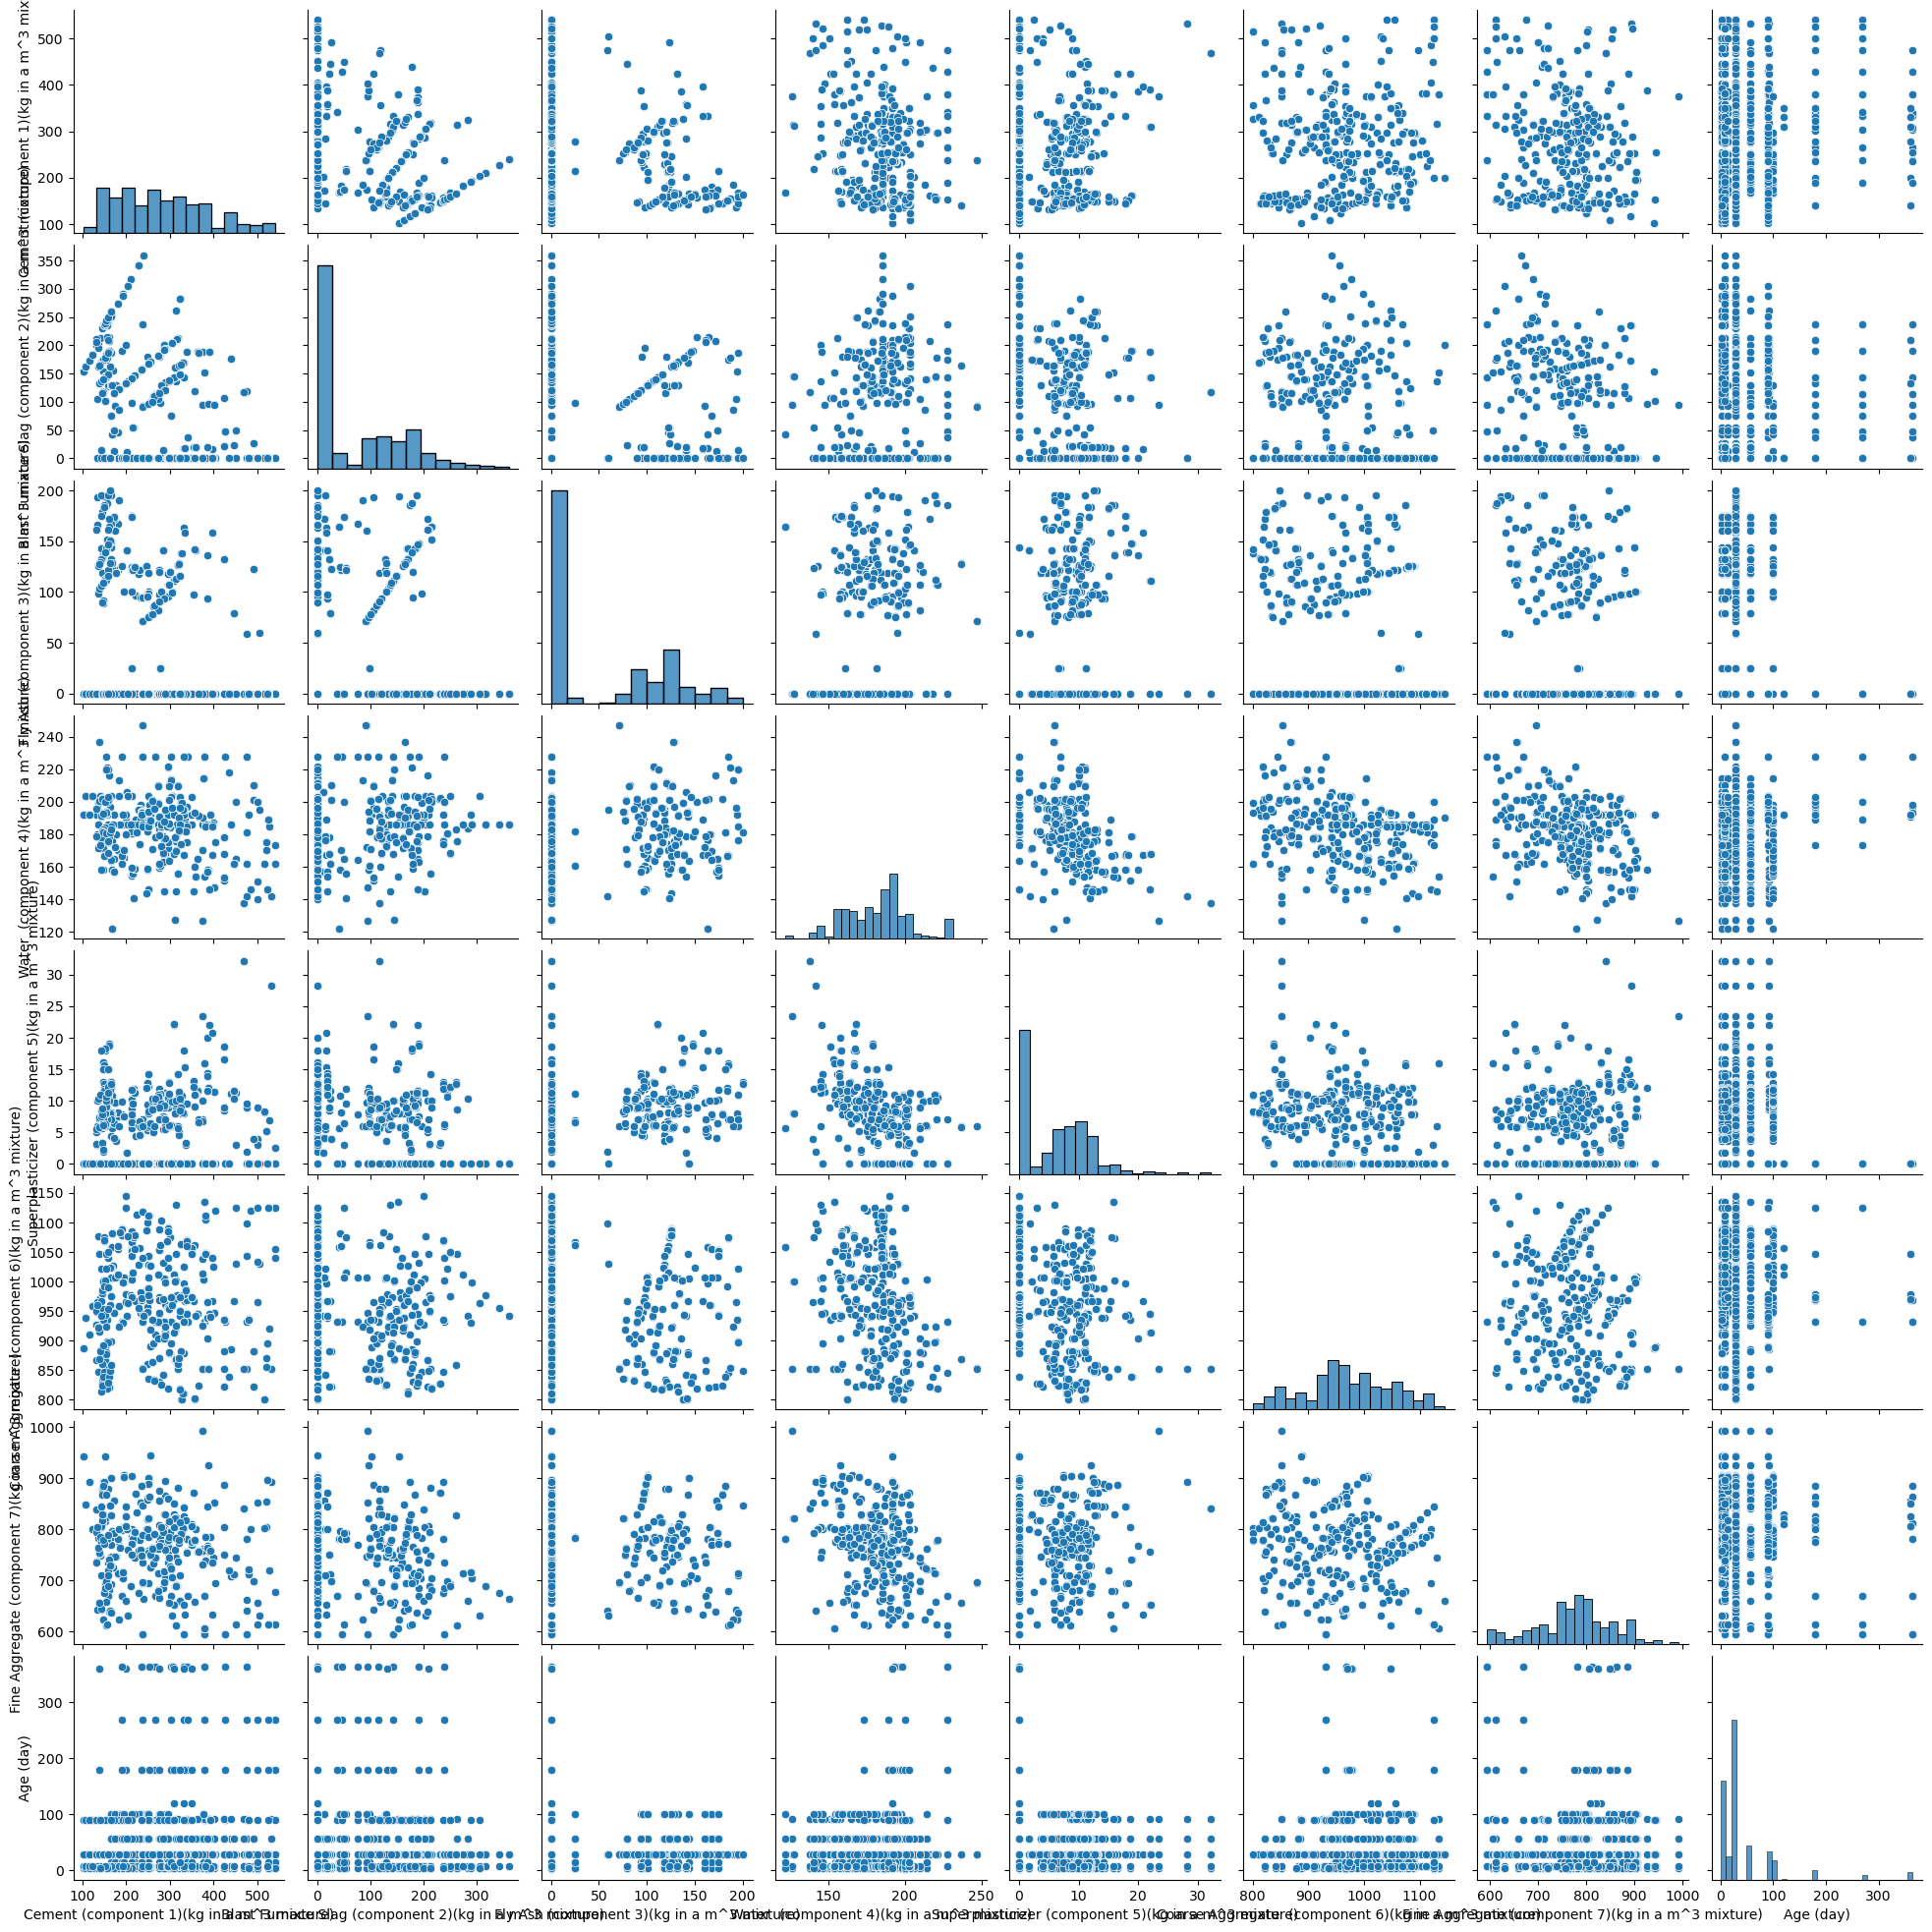

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(X)

plt.show()

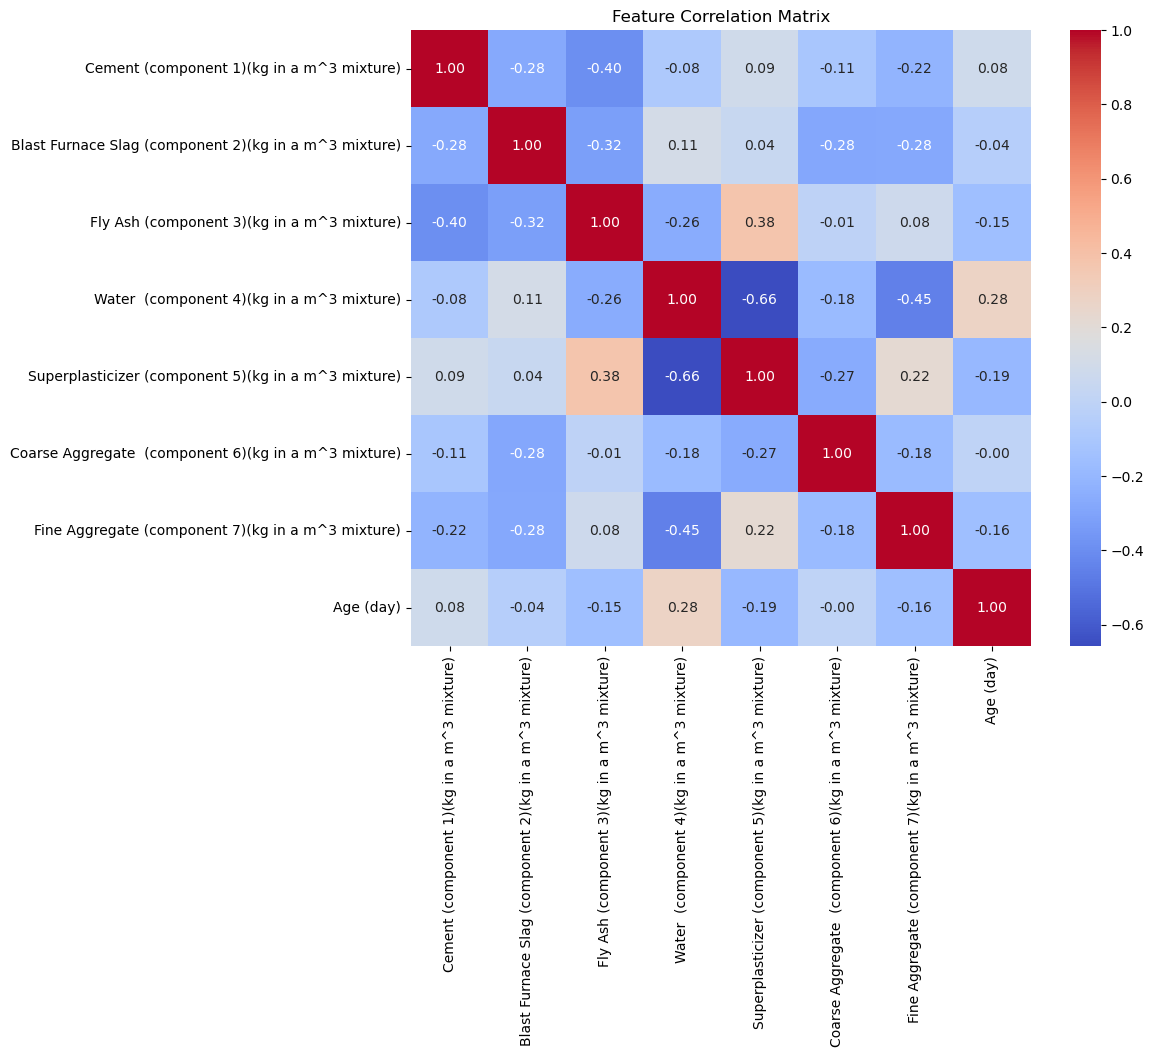

In [8]:
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()



In [ ]:
MODEL SELECTION

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

df = pd.read_excel("Concrete_Data.xlsx")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ("scaler",    StandardScaler()),
    ("regressor", LinearRegression()),
])

pipeline.fit(X_train, y_train)
 
y_pred = pipeline.predict(X_test)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 9.80
R²   : 0.6275


In [11]:
#k-fold cross-validation
from sklearn.model_selection import cross_val_score
model = LinearRegression()
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

rmse_scores = -scores

print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

RMSE per fold: [11.7991231  11.93167702  9.37209595  9.85408469 10.36895609]
Mean RMSE: 10.665187370923723


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

y_pred_test = rf.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))


RMSE: 5.510
R²: 0.882


In [13]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(
    random_state=42,
    n_estimators=100
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

# Test RMSE
y_pred_test = xgb.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))



RMSE: 4.461
R²: 0.923


In [14]:
model = XGBRegressor(random_state=42)
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

rmse_scores = -scores

print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

RMSE per fold: [5.23217748 4.97766873 4.67366323 4.12211718 4.69053418]
Mean RMSE: 4.739232159282194


In [17]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
        "n_estimators":    [100, 200, 400],
        "max_depth":       [4, 6, 8],
        "learning_rate":   [0.05, 0.1, 1],
        "subsample":       [0.5, 0.7, 0.9],
        "colsample_bytree":[0.5, 0.7, 0.9],
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best Parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.5}
Best CV R²: 0.9344303691709458


In [16]:
from sklearn.metrics import root_mean_squared_error, r2_score

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

RMSE: 4.218034806711283
R²  : 0.9309541194418157


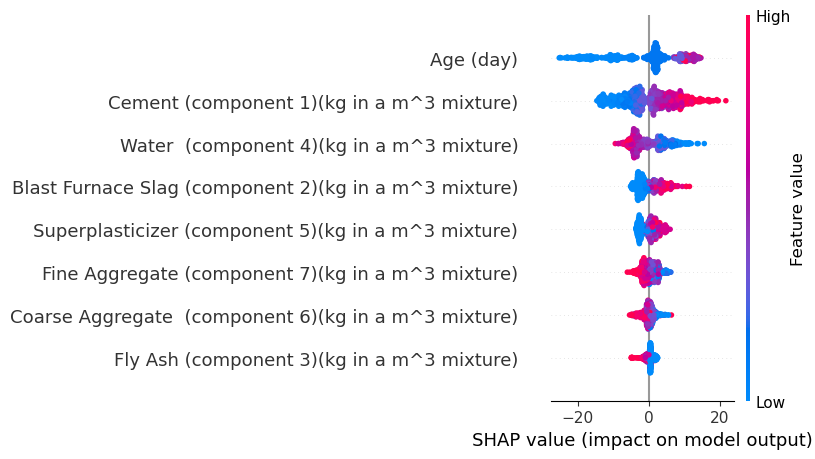

In [22]:
import shap
import matplotlib.pyplot as plt

# Best model from GridSearchCV
best_model = grid.best_estimator_

# Create SHAP explainer (tree-based models like XGBoost)
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_train)

# Summary plot
shap.summary_plot(shap_values, X_train)